<a href="https://colab.research.google.com/github/asheta66/CNN/blob/main/Skin_Disease/Skin_Disease_efficientnetb0_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# ==============================================
# Skin Disease Classification (EfficientNetB0)
# ==============================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 2. Imports
# ----------------------------
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 3. Dataset Path
# ----------------------------
dataset_dir = '/content/drive/MyDrive/Skin_Disease'

# ----------------------------
# 4. Parameters
# ----------------------------
img_height, img_width = 224, 224
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# ----------------------------
# 5. Count Images Per Class
# ----------------------------
class_names = sorted(os.listdir(dataset_dir))

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(dataset_dir, class_name)

    # Count only image files
    num_images = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    class_counts[class_name] = num_images

# ----------------------------
# 6. Print Table
# ----------------------------
df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Samples"]
)

print("\n📊 Dataset Distribution:\n")
print(df_counts)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📊 Dataset Distribution:

                        Class  Number of Samples
0           Actinic keratosis                100
1           Atopic_Dermatitis                 81
2            Benign_keratosis                100
3              Dermatofibroma                100
4           Melanocytic nevus                100
5                    Melanoma                100
6     Squamous cell carcinoma                100
7  Tinea Ringworm Candidiasis                 64
8             Vascular lesion                100


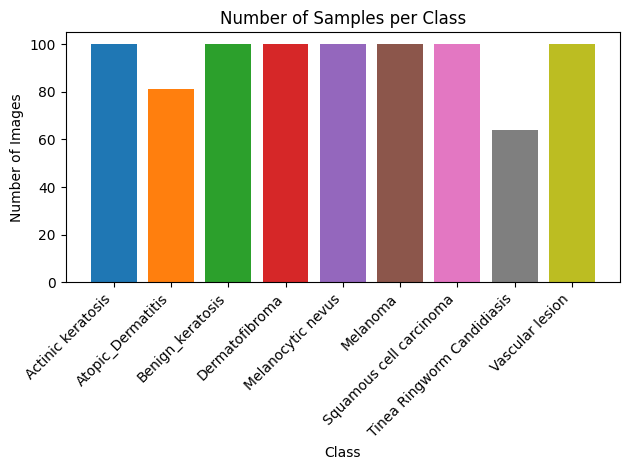

In [51]:
# ----------------------------
# 7. Plot Bar Chart
# ----------------------------
plt.figure()

colors = plt.cm.tab10(range(len(df_counts)))  # nice distinct colors

plt.bar(df_counts["Class"], df_counts["Number of Samples"], color=colors)

plt.xticks(rotation=45, ha='right')
plt.title("Number of Samples per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
fig = plt.gcf()
fig.savefig("class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# ----------------------------
# 8. Load Dataset (80/20 Split)
# ----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\n✅ Classes detected:", class_names)
print("✅ Number of classes:", num_classes)

# ----------------------------
# 9. Optimize Dataset Pipeline
# ----------------------------
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------
# 10. Preprocessing for EfficientNet
# ----------------------------
from tensorflow.keras.applications.efficientnet import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

print("\n🚀 Dataset ready for training!")

Found 845 files belonging to 9 classes.
Using 676 files for training.
Found 845 files belonging to 9 classes.
Using 169 files for validation.

✅ Classes detected: ['Actinic keratosis', 'Atopic_Dermatitis', 'Benign_keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']
✅ Number of classes: 9

🚀 Dataset ready for training!


In [33]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

# ----------------------------
# 6. Data Augmentation
# ----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Apply augmentation ONLY on training data
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

# ----------------------------
# 7. Preprocessing (EfficientNet)
# ----------------------------
from tensorflow.keras.applications.efficientnet import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

# ----------------------------
# 8. Build Model (Better Fine-Tuning Strategy)
# ----------------------------
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

# 🔒 Freeze most layers first (important!)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Unfreeze top layers only
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Build full model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)  # improves stability
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# model.summary()

# ----------------------------
# 9. Callbacks (VERY IMPORTANT)
# ----------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3,
        patience=3
    )
]

# ----------------------------
# 10. Train Model
# ----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2101 - loss: 2.5740 - val_accuracy: 0.2663 - val_loss: 2.0195 - learning_rate: 1.0000e-04
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step - accuracy: 0.3802 - loss: 1.8771 - val_accuracy: 0.4083 - val_loss: 1.8261 - learning_rate: 1.0000e-04
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.4704 - loss: 1.5486 - val_accuracy: 0.4911 - val_loss: 1.6397 - learning_rate: 1.0000e-04
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.5784 - loss: 1.2758 - val_accuracy: 0.5266 - val_loss: 1.4797 - learning_rate: 1.0000e-04
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step - accuracy: 0.6154 - loss: 1.1570 - val_accuracy: 0.5503 - val_loss: 1.3530 - learning_rate: 1.0000e-04
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.6524 - loss: 1.0472 - val_accuracy: 0.5680 - val_loss: 1.2485 - learning_rate: 1.0000e-04
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 350ms/step - accuracy: 0.

**Count Samples Before and After Augmentation**

In [34]:
# ----------------------------
# Count number of samples BEFORE augmentation
# ----------------------------
num_samples_train = 0
for _, y in train_ds.unbatch():
    num_samples_train += 1

num_samples_val = 0
for _, y in val_ds.unbatch():
    num_samples_val += 1

print(f"Number of training samples BEFORE augmentation: {num_samples_train}")
print(f"Number of validation samples: {num_samples_val}")

# ----------------------------
# 7. Data Augmentation (Apply On-the-fly)
# ----------------------------
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Prefetch for performance
train_ds_aug = train_ds_aug.prefetch(tf.data.AUTOTUNE)

# ----------------------------
# Count number of samples AFTER augmentation
# ----------------------------
# Note: still the same number of samples in dataset, because augmentation is on-the-fly
num_samples_train_aug = 0
for _, y in train_ds_aug.unbatch():
    num_samples_train_aug += 1

# ----------------------------
# Put in a DataFrame
# ----------------------------
import pandas as pd

df_counts_aug = pd.DataFrame({
    "Dataset": ["Train (original)", "Train (augmented)", "Validation"],
    "Number of Samples": [num_samples_train, num_samples_train_aug, num_samples_val]
})

print("\n📊 Dataset Samples Before and After Augmentation:\n")
df_counts_aug

Number of training samples BEFORE augmentation: 676
Number of validation samples: 169

📊 Dataset Samples Before and After Augmentation:



,Dataset,Number of Samples
0,Train (original),676
1,Train (augmented),676
2,Validation,169


In [35]:
# ----------------------------
# 9. Extract predictions and true labels
# ----------------------------
def get_labels_and_predictions(dataset, model):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

# For training dataset
y_true_train, y_pred_train = get_labels_and_predictions(train_ds, model)

# For validation dataset
y_true_val, y_pred_val = get_labels_and_predictions(val_ds, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/s

In [36]:
# ----------------------------
# Define metrics_df function
# ----------------------------
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def metrics_df(y_true, y_pred, dataset_name):
    """Compute key classification metrics and return as DataFrame."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Optional: confusion matrix display
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix ({dataset_name}):\n", cm)

    # Return DataFrame with metrics
    df = pd.DataFrame({
        'Dataset': [dataset_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1]
    })
    return df


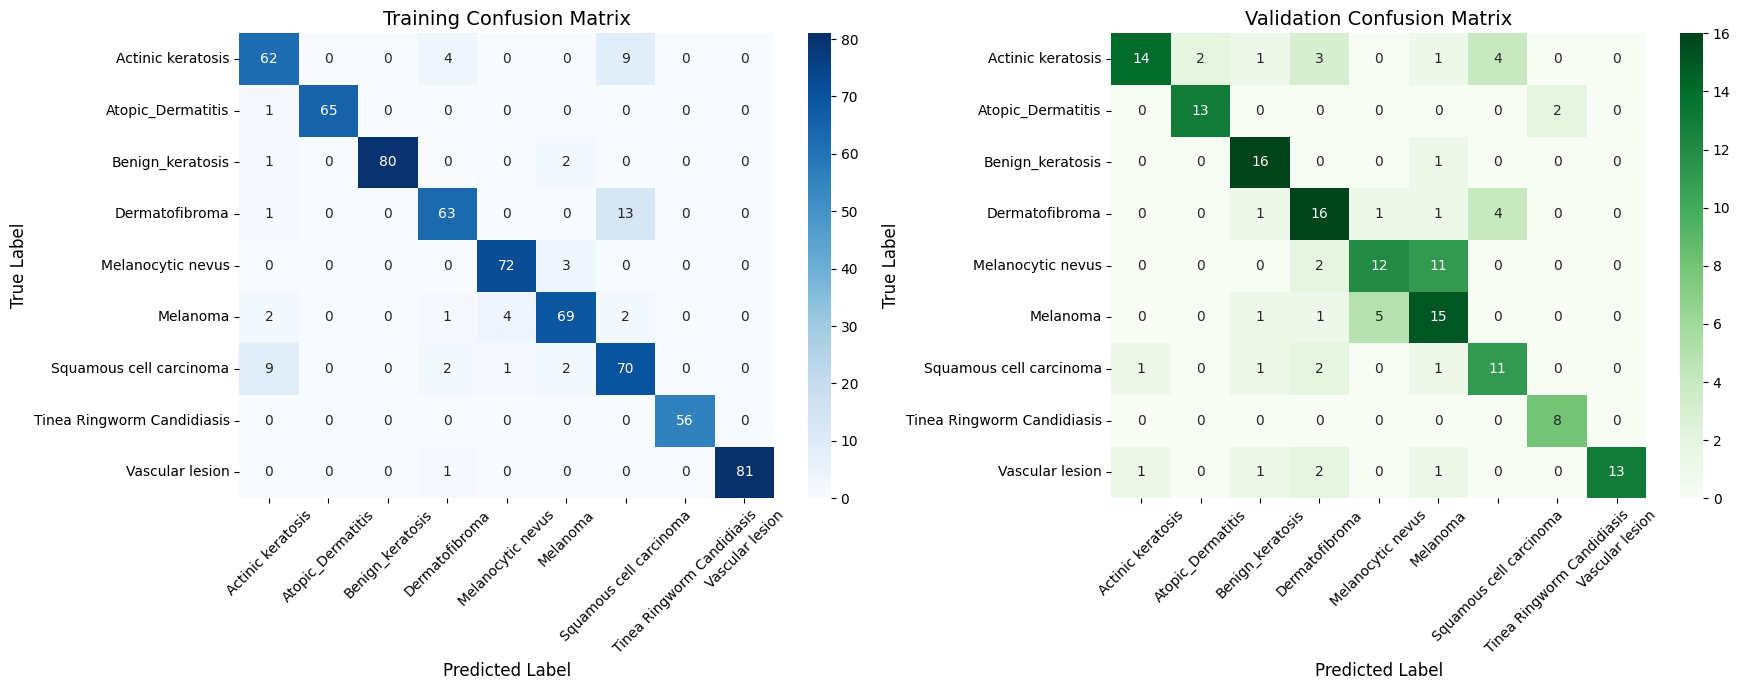

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrices(y_true_train, y_pred_train, y_true_val, y_pred_val, class_names):
    """
    Plot training and validation confusion matrices as side-by-side subplots.
    Returns the figure object for saving.
    """
    # Compute confusion matrices
    cm_train = confusion_matrix(y_true_train, y_pred_train)
    cm_val = confusion_matrix(y_true_val, y_pred_val)

    # Set up subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Training CM
    sns.heatmap(
        cm_train, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[0]
    )
    axes[0].set_title("Training Confusion Matrix", fontsize=14)
    axes[0].set_xlabel("Predicted Label", fontsize=12)
    axes[0].set_ylabel("True Label", fontsize=12)
    axes[0].tick_params(axis='x', labelsize=10, rotation=45)
    axes[0].tick_params(axis='y', labelsize=10, rotation=0)

    # Validation CM
    sns.heatmap(
        cm_val, annot=True, fmt='d', cmap='Greens',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[1]
    )
    axes[1].set_title("Validation Confusion Matrix", fontsize=14)
    axes[1].set_xlabel("Predicted Label", fontsize=12)
    axes[1].set_ylabel("True Label", fontsize=12)
    axes[1].tick_params(axis='x', labelsize=10, rotation=45)
    axes[1].tick_params(axis='y', labelsize=10, rotation=0)

    fig.tight_layout()  # fix spacing
    return fig  # return figure for saving

# ----------------------------
# Example usage
# ----------------------------
fig = plot_confusion_matrices(y_true_train, y_pred_train, y_true_val, y_pred_val, class_names)

# Save figure
fig.savefig("confusion_matrix_training_testing.png", dpi=300, bbox_inches='tight')

plt.show()

In [38]:
df_metrics

,Dataset,Accuracy,Precision,Recall,F1-Score
0,Training,0.908284,0.912519,0.908284,0.909292
1,Validation,0.704142,0.736052,0.704142,0.706260


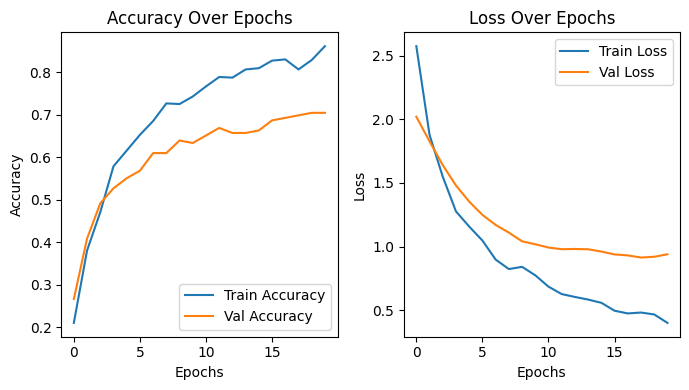

In [39]:
# ----------------------------
# 10. Accuracy & Loss Plots
# ----------------------------
plt.figure(figsize=(7,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_loss.png')
plt.show()

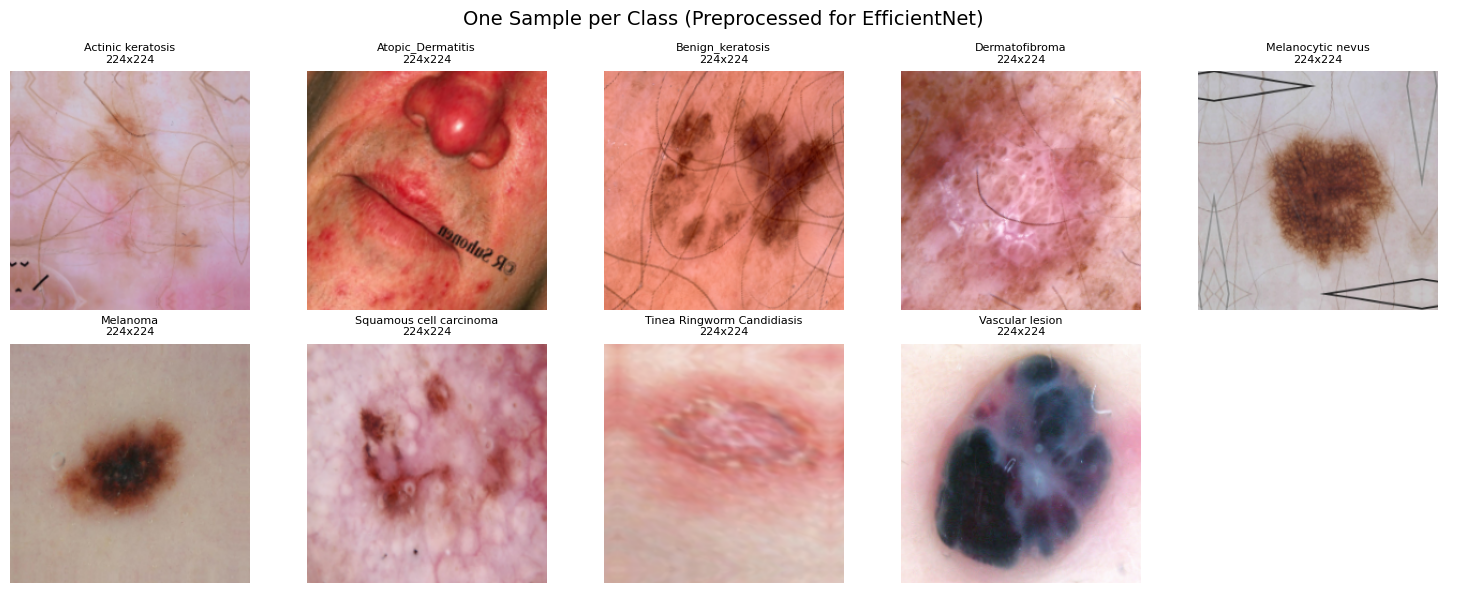

In [49]:
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from tensorflow.keras.applications.efficientnet import preprocess_input

# ----------------------------
# Parameters
# ----------------------------
samples_per_class = 1       # one image per class
img_height, img_width = 224, 224  # EfficientNet input size

# ----------------------------
# Function to extract one sample per class from training dataset
# ----------------------------
def get_one_sample_from_dataset(dataset, class_index):
    """Return one image from a given class index in the dataset."""
    for batch_images, batch_labels in dataset:
        batch_labels_np = batch_labels.numpy()
        batch_images_np = batch_images.numpy()
        for i, label in enumerate(batch_labels_np):
            if label == class_index:
                return batch_images_np[i]
    return None

# ----------------------------
# Plotting as a square matrix
# ----------------------------
num_classes = len(class_names)
cols = min(5, num_classes)              # max 5 columns
rows = (num_classes + cols - 1) // cols # compute required rows

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    img = get_one_sample_from_dataset(train_ds, idx)
    if img is None:
        continue
    # Resize and preprocess
    img_resized = tf.image.resize(img, (img_height, img_width))
    img_preprocessed = preprocess_input(img_resized.numpy())

    axes[idx].imshow(img_preprocessed.astype("uint8"))
    axes[idx].set_title(f"{class_name}\n{img_height}x{img_width}", fontsize=8)
    axes[idx].axis("off")

# Hide any unused axes
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("One Sample per Class (Preprocessed for EfficientNet)", fontsize=14)
plt.tight_layout()

# Save the figure
fig.savefig("sample_images_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
def plot_roc_subplots(train_ds, val_ds, model, num_classes):
    """
    Plot ROC curves for training and validation datasets side by side.

    Each dataset gets its own subplot.
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import numpy as np

    # Helper to get true labels and predicted probabilities
    y_true_train, y_probs_train = get_probabilities_and_labels(train_ds, model)
    y_true_val, y_probs_val = get_probabilities_and_labels(val_ds, model)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # ----------------------------
    # Training ROC
    # ----------------------------
    ax = axes[0]
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true_train, y_probs_train[:, 1])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    else:
        y_true_bin = label_binarize(y_true_train, classes=range(num_classes))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_train[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title("Training ROC")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)

    # ----------------------------
    # Validation ROC
    # ----------------------------
    ax = axes[1]
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true_val, y_probs_val[:, 1])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    else:
        y_true_bin = label_binarize(y_true_val, classes=range(num_classes))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_val[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title("Validation ROC")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)

    plt.tight_layout()
    return fig

In [42]:
def get_probabilities_and_labels(dataset, model):
    import numpy as np
    y_true = []
    y_pred_probs = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.append(labels.numpy())
        y_pred_probs.append(probs)

    y_true = np.concatenate(y_true)
    y_pred_probs = np.concatenate(y_pred_probs)

    return y_true, y_pred_probs


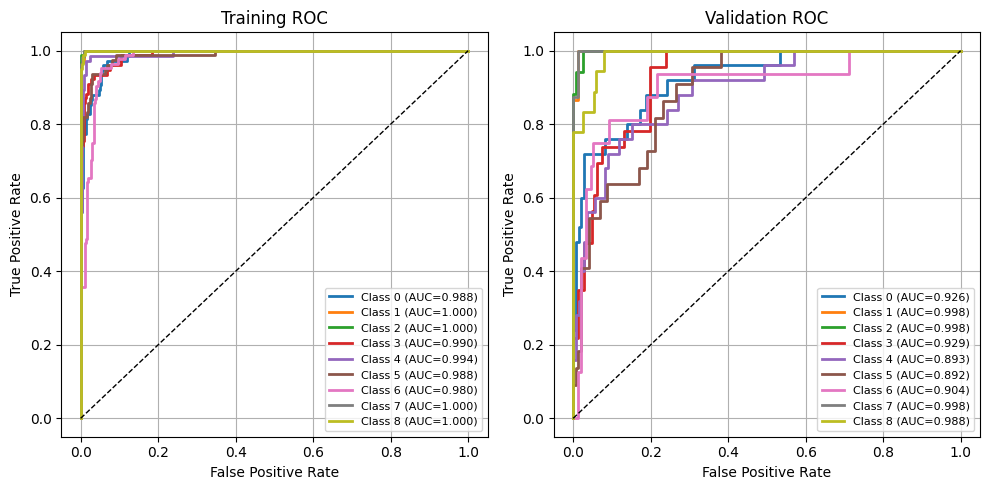

In [45]:
# Generate the ROC figure
fig = plot_roc_subplots(train_ds, val_ds, model, num_classes)

# Save the figure to a file
fig.savefig("roc_training_validation.png", dpi=300, bbox_inches='tight')

# Optionally display it
plt.show()

In [44]:
# ----------------------------
# Count number of images in training and validation sets
# ----------------------------

def count_images(dataset):
    total = 0
    for images, labels in dataset:
        total += images.shape[0]  # batch size
    return total

num_train_images = count_images(train_ds)
num_val_images   = count_images(val_ds)

print(f"Number of training images: {num_train_images}")
print(f"Number of validation/testing images: {num_val_images}")


Number of training images: 676
Number of validation/testing images: 169
